In [1]:
import torch
import train

# Checking models performance on small number of epochs

## Round 1

In [3]:
seed = 123456789
trainloader, validationloader = train.set_train_val(batch_size=32, seed=seed)

In [2]:
import os, json
import plotly.graph_objects as go
def open_selected(prefix, suffix, index_list=None, path=train.save_path):
    l = []
    path = os.path.join(path, 'tmp')

    if index_list is None:
        i = 0
        path = os.path.join(os.path.dirname(path), prefix + str(i) + suffix)
        while os.path.exists(path):
            with open(path, 'r') as f:
                data = json.load(f)
            l.append(data)

            i += 1
            path = os.path.join(os.path.dirname(path), prefix + str(i) + suffix)
    else:
        for i in index_list:
            path = os.path.join(os.path.dirname(path), prefix + str(i) + suffix)
            with open(path, 'r') as f:
                data = json.load(f)
            l.append(data)
    return l

def visualise_losses(index_list=None, path=train.save_path):
    losses_list = open_selected(prefix="loss", suffix=".json", index_list=index_list, path=path)
    hyperparms_list = open_selected(prefix="train_metadata", suffix=".json", index_list=index_list, path=path)
    
    fig = go.Figure()

    for j, loss in enumerate(losses_list):
            x = list(range(len(loss)))
            layers = hyperparms_list[j]['channels']
            hyperparams = hyperparms_list[j]['hyperparameters']
            fig.add_trace(go.Scatter(x=x, y=loss, mode='lines', name=f'Layers: {layers}; Hyperparams: {hyperparams}'))

    fig.update_layout(
        title='Cross Entropy Loss Over Batches',
        xaxis_title='Batch',
        yaxis_title='Cross Entropy Loss',
        template='plotly_dark',
        hovermode='x unified'
    )

    fig.show()


In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns

def calculate_label_accuracies(cm):
    """Calculate per-label accuracy from confusion matrix"""
    with np.errstate(divide='ignore', invalid='ignore'):
        accuracies = np.diag(cm) / np.sum(cm, axis=1)
        accuracies = np.nan_to_num(accuracies)  # Convert NaNs to zero for labels with no samples
    return accuracies


def visualise_label_accuracies(index_list=None, path=train.save_path):
    validations = open_selected(prefix="validation", suffix=".json", index_list=index_list, path=path)
    predictions = [v['predicted'] for v in validations]
    expected = [v['expected'] for v in validations]
    cms = [confusion_matrix(np.array(e, dtype=int), np.array(p, dtype=int)) for e, p in zip(expected, predictions)]

    # Compute per-label accuracies for each confusion matrix
    all_accuracies = [calculate_label_accuracies(cm) for cm in cms]
    all_accuracies = np.array(all_accuracies)  # Shape: (num_matrices, num_labels)
    num_labels = all_accuracies.shape[1]
    
    # Create figure
    fig = go.Figure()

    # Add bars for each confusion matrix
    for i, acc in enumerate(all_accuracies):
        fig.add_trace(go.Bar(
            x=[chr((ord('a')) + i) for i in range(0, num_labels)],  # Label indices
            y=acc,  
            name=f'Matrix {i+1}',
            visible=(i == 0)  # Show only the first matrix initially
        ))

    # Create dropdown menu to switch between matrices
    buttons = [
        dict(
            label=f'Matrix {i+1}',
            method='update',
            args=[{'visible': [j == i for j in range(len(all_accuracies))]}]
        ) 
        for i in range(len(all_accuracies))
    ]

    fig.update_layout(
        title="Accuracy per Label",
        xaxis_title="Label",
        yaxis_title="Accuracy",
        xaxis=dict(tickmode="linear"),
        yaxis=dict(range=[0, 1]),
        updatemenus=[{"buttons": buttons, "direction": "down", "showactive": True}]
    )

    fig.show()


In [4]:
def calculate_average_accuracy(cm):
    """Calculate average accuracy from confusion matrix"""
    correct_preds = np.diag(cm).sum()
    total_preds = cm.sum()
    return correct_preds / total_preds if total_preds > 0 else 0

def visualise_accuracies(index_list=None, path=train.save_path):
    """Plot average accuracy for each confusion matrix on one histogram"""
    validations = open_selected(prefix="validation", suffix=".json", index_list=index_list, path=path)
    predictions = [v['predicted'] for v in validations]
    expected = [v['expected'] for v in validations]
    cms = [confusion_matrix(np.array(e, dtype=int), np.array(p, dtype=int)) for e, p in zip(expected, predictions)]

    # Compute average accuracy for each confusion matrix
    avg_accuracies = [calculate_average_accuracy(cm) for cm in cms]

    # Create a bar plot
    fig = go.Figure(data=[
        go.Bar(x=[f'Model {i}' for i in range(len(avg_accuracies))],  # X-axis: Matrix index
               y=avg_accuracies,  # Y-axis: Average accuracy
               text=[f'{a:.2%}' for a in avg_accuracies],  # Display percentage
               textposition='auto')
    ])

    fig.update_layout(
        title="Validation Accuracies",
        xaxis_title="Model",
        yaxis_title="Average Accuracy",
        yaxis=dict(range=[0, 1]),  # Keep accuracy range from 0 to 1
    )

    fig.show()

In [ ]:
n = 5
c_low = 2
c_high = 10
exp_low = -13
exp_high = -4
epochs = 2

models, alphas = train.models_rand(n, c_low, c_high, exp_low, exp_high)
hyperparams_list = [{"lr": a} for a in alphas]

for i, (model, hyperparams) in enumerate(zip(models, hyperparams_list)):
    print(f"Training model {i}; channels: {model.summary}; hyperparams: {hyperparams}")
    train.train(model, trainloader=trainloader, validationloader=validationloader, hyperparams=hyperparams, epochs=epochs, seed=seed)

Training model 0; channels: [9, 5]; hyperparams: {'lr': 0.0001220703125}
Epoch 1, batch 100, loss 3.264
Epoch 1, batch 200, loss 3.259
Epoch 1, batch 300, loss 3.257
Epoch 1, batch 400, loss 3.256
Epoch 1, batch 500, loss 3.251
Epoch 1, batch 600, loss 3.250
Epoch 1, batch 700, loss 3.250
Epoch 1, batch 800, loss 3.246
Epoch 1, batch 900, loss 3.246
Epoch 1, batch 1000, loss 3.238
Epoch 1, batch 1100, loss 3.239
Epoch 1, batch 1200, loss 3.231
Epoch 1, batch 1300, loss 3.233
Epoch 1, batch 1400, loss 3.226
Epoch 1, batch 1500, loss 3.221
Epoch 1, batch 1600, loss 3.217
Epoch 1, batch 1700, loss 3.209
Epoch 1, batch 1800, loss 3.207
Epoch 1, batch 1900, loss 3.198
Epoch 1, batch 2000, loss 3.198
Epoch 1, batch 2100, loss 3.192
Epoch 1, batch 2200, loss 3.184
Epoch 1, batch 2300, loss 3.183
Epoch 1, batch 2400, loss 3.173
Epoch 1, batch 2500, loss 3.158
Epoch 1, batch 2600, loss 3.172
Epoch 1, batch 2700, loss 3.165
Epoch 1, batch 2800, loss 3.151
Epoch 1, batch 2900, loss 3.149
Epoch 1,

In [6]:
visualise_losses([0, 1, 2, 3, 4])

As we can see data variance of loss is too big, it is not steadily converging. To resolve this let's increase batch size

## Round 2

In [7]:
seed = 123456789
trainloader, validationloader = train.set_train_val(batch_size=256, seed=seed)

In [8]:
models, alphas = train.models_rand(n, c_low, c_high, exp_low, exp_high)
hyperparams_list = [{"lr": a} for a in alphas]

for i, (model, hyperparams) in enumerate(zip(models, hyperparams_list)):
    print(f"Training model {i}; channels: {model.summary}; hyperparams: {hyperparams}")
    train.train(model, trainloader=trainloader, validationloader=validationloader, hyperparams=hyperparams, epochs=epochs, seed=seed)

Training model 0; channels: [9, 5]; hyperparams: {'lr': 0.0001220703125}
Epoch 1, batch 100, loss 3.260
Epoch 1, batch 200, loss 3.257
Epoch 1, batch 300, loss 3.251
Epoch 2, batch 100, loss 3.236
Epoch 2, batch 200, loss 3.228
Epoch 2, batch 300, loss 3.217
Training model 1; channels: [7, 3]; hyperparams: {'lr': 0.001953125}
Epoch 1, batch 100, loss 3.249
Epoch 1, batch 200, loss 3.178
Epoch 1, batch 300, loss 3.095
Epoch 2, batch 100, loss 3.005
Epoch 2, batch 200, loss 2.960
Epoch 2, batch 300, loss 2.940
Training model 2; channels: [7, 2]; hyperparams: {'lr': 0.0001220703125}
Epoch 1, batch 100, loss 3.261
Epoch 1, batch 200, loss 3.260
Epoch 1, batch 300, loss 3.259
Epoch 2, batch 100, loss 3.255
Epoch 2, batch 200, loss 3.251
Epoch 2, batch 300, loss 3.248
Training model 3; channels: [8, 4]; hyperparams: {'lr': 0.001953125}
Epoch 1, batch 100, loss 3.235
Epoch 1, batch 200, loss 3.099
Epoch 1, batch 300, loss 2.963
Epoch 2, batch 100, loss 2.856
Epoch 2, batch 200, loss 2.818
Epo

In [9]:
visualise_losses([5, 6, 7, 8, 9])

This is much better, although it is still noisy increasing batch size would hinder speed of computation so we've decided to stick with this

Now let's check performance via confusion matrix

In [6]:
# load if necessary
def load_model(folder, model_i):
    metadata_path = os.path.dirname(train.save_path)
    model_path = os.path.join(metadata_path, folder, f'cnn{model_i}.pth')
    metadata_path = os.path.join(metadata_path, folder, f"train_metadata{model_i}.json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    model = train.ConvNetPooling(train.height, train.width, train.output_size, channels=metadata['channels'])
    model.load_state_dict(torch.load(model_path, weights_only=True))
    return model

folder = "training_pyramid3"
models = [load_model(folder, i) for i in range(5, 10)]

In [ ]:
visualise_label_accuracies(list(range(5, 10)), path=os.path.join(os.path.dirname(train.save_path), folder))

It is not noticable now, but we've ran experiments for more epochs for best model and in result it overfit. 

![Screenshot 2025-02-26 194548.png](<attachment:Screenshot 2025-02-26 194548.png>)

Above you can see sorted accuracies after 20 epochs for best model. To tackle this we've implemented dropout. As recommneded by some sources, dropout in convolutional layers should be around 0.2-0.3, we've stuck with 0.2
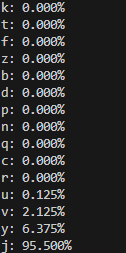

In [4]:
seed = 123456789
trainloader, validationloader = train.set_train_val(batch_size=256, seed=seed)

In [5]:
n = 5
c_low = 2
c_high = 10
exp_low = -13
exp_high = -4
epochs = 2

models, alphas = train.models_rand(n, c_low, c_high, exp_low, exp_high)
hyperparams_list = [{"lr": a} for a in alphas]

for i, (model, hyperparams) in enumerate(zip(models, hyperparams_list)):
    print(f"Training model {i}; channels: {model.summary}; hyperparams: {hyperparams}")
    train.train(model, trainloader=trainloader, validationloader=validationloader, hyperparams=hyperparams, epochs=epochs, seed=seed)

Training model 0; channels: [9, 5]; hyperparams: {'lr': 0.0001220703125}
Epoch 1, batch 100, loss 3.262
Epoch 1, batch 200, loss 3.260
Epoch 1, batch 300, loss 3.256
Epoch 2, batch 100, loss 3.246
Epoch 2, batch 200, loss 3.240
Epoch 2, batch 300, loss 3.233
Training model 1; channels: [7, 3]; hyperparams: {'lr': 0.001953125}
Epoch 1, batch 100, loss 3.252
Epoch 1, batch 200, loss 3.198
Epoch 1, batch 300, loss 3.134
Epoch 2, batch 100, loss 3.069
Epoch 2, batch 200, loss 3.047
Epoch 2, batch 300, loss 3.029
Training model 2; channels: [7, 2]; hyperparams: {'lr': 0.0001220703125}
Epoch 1, batch 100, loss 3.261
Epoch 1, batch 200, loss 3.261
Epoch 1, batch 300, loss 3.260
Epoch 2, batch 100, loss 3.257
Epoch 2, batch 200, loss 3.255
Epoch 2, batch 300, loss 3.253
Training model 3; channels: [8, 4]; hyperparams: {'lr': 0.001953125}
Epoch 1, batch 100, loss 3.250
Epoch 1, batch 200, loss 3.161
Epoch 1, batch 300, loss 3.067
Epoch 2, batch 100, loss 2.976
Epoch 2, batch 200, loss 2.943
Epo

In [6]:
visualise_losses(list(range(5)))

In [24]:
visualise_label_accuracies(list(range(5)))

In [23]:
visualise_accuracies()

Model 3 and model 4 are the best candidates, we are inclined to stick with model 3 as its accuracy variance per label is lower than model 4 and performance is only slightly worse.

In [12]:
seed = 123456789
trainloader, validationloader = train.set_train_val(batch_size=64, seed=seed)

In [13]:
n = 20
c_low = 5
c_high = 20
num_l = 2
exp_low = -10
exp_high = -4
epochs = 2

models, alphas = train.models_rand(n, c_low, c_high, exp_low, exp_high, num_l=num_l)
hyperparams_list = [{"lr": a} for a in alphas]

for i, (model, hyperparams) in enumerate(zip(models, hyperparams_list)):
    print(f"Training model {i}; channels: {model.summary}; hyperparams: {hyperparams}")
    train.train(model, trainloader=trainloader, validationloader=validationloader, hyperparams=hyperparams, epochs=epochs, seed=seed)

Training model 0; channels: [9, 6]; hyperparams: {'lr': 0.0078125}
Epoch 1, batch 100, loss 3.256
Epoch 1, batch 200, loss 3.203
Epoch 1, batch 300, loss 3.141
Epoch 1, batch 400, loss 3.090
Epoch 1, batch 500, loss 3.076
Epoch 1, batch 600, loss 3.037
Epoch 1, batch 700, loss 3.031
Epoch 1, batch 800, loss 3.013
Epoch 1, batch 900, loss 3.009
Epoch 1, batch 1000, loss 2.987
Epoch 1, batch 1100, loss 2.977
Epoch 1, batch 1200, loss 2.989
Epoch 1, batch 1300, loss 2.970
Epoch 1, batch 1400, loss 2.945
Epoch 1, batch 1500, loss 2.950
Epoch 2, batch 100, loss 2.954
Epoch 2, batch 200, loss 2.938
Epoch 2, batch 300, loss 2.937
Epoch 2, batch 400, loss 2.927
Epoch 2, batch 500, loss 2.930
Epoch 2, batch 600, loss 2.913
Epoch 2, batch 700, loss 2.913
Epoch 2, batch 800, loss 2.909
Epoch 2, batch 900, loss 2.915
Epoch 2, batch 1000, loss 2.925
Epoch 2, batch 1100, loss 2.910
Epoch 2, batch 1200, loss 2.923
Epoch 2, batch 1300, loss 2.947
Epoch 2, batch 1400, loss 2.905
Epoch 2, batch 1500, lo

In [14]:
visualise_losses()

In [11]:
visualise_accuracies()

# Training

Now that we've decided to stick with model 3 let's train it for more epochs

In [38]:
hyperparams = {"lr": 0.03125}
channels = [8, 6]
model = train.ConvNetPooling(height=train.height, width=train.width, output=train.output_size, channels=channels)

In [40]:
model_path = os.path.dirname(train.save_path)
model_path = os.path.join(model_path, 'training_pyramid5', 'cnn14.pth')
model.load_state_dict(torch.load(model_path, weights_only=True))

<All keys matched successfully>

In [41]:
seed = 123456789
trainloader, validationloader = train.set_train_val(batch_size=512, seed=seed)

In [43]:
epochs = 10
train.train(model=model, hyperparams=hyperparams, trainloader=trainloader, validationloader=validationloader, epochs=epochs)

Epoch 1, batch 100, loss 2.814
Epoch 2, batch 100, loss 2.804
Epoch 3, batch 100, loss 2.800
Epoch 4, batch 100, loss 2.802
Epoch 5, batch 100, loss 2.806
Epoch 6, batch 100, loss 2.794
Epoch 7, batch 100, loss 2.798
Epoch 8, batch 100, loss 2.800
Epoch 9, batch 100, loss 2.794
Epoch 10, batch 100, loss 2.798


In [44]:
visualise_losses([26])

In [45]:
visualise_label_accuracies([26])
visualise_accuracies([26])